In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv("../data/zomato_feature_engineered.csv")
print(df.columns.tolist())
print("Dataset Shape:", df.shape)

# ─────────────────────────────────────────────
# 2. CREATE TARGET VARIABLE
#    high_rated = 1 if delivery_rating >= 4.0, else 0
#    (threshold from EDA: mean delivery rating = 3.93, peak at 4.0)
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 3. FEATURE SELECTION FOR ML
# ─────────────────────────────────────────────


# ─────────────────────────────────────────────
# 4. TRAIN-TEST SPLIT + SCALING
# ─────────────────────────────────────────────


# ─────────────────────────────────────────────
# 5. MODEL 1 — LOGISTIC REGRESSION
# ─────────────────────────────────────────────


# ─────────────────────────────────────────────
# 6. MODEL 2 — RANDOM FOREST
# ─────────────────────────────────────────────


# ─────────────────────────────────────────────
# 7. MODEL COMPARISON PLOT
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 8. FEATURE IMPORTANCE (Random Forest)
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 9. CONFUSION MATRIX — Best Model
# ─────────────────────────────────────────────


# ─────────────────────────────────────────────
# 10. K-MEANS CLUSTERING — Market Zone Segmentation
# ─────────────────────────────────────────────

# Aggregate by area for clustering


# Elbow method to pick K


# Apply K=4 (4 market zone types)


# ── Assign meaningful business labels ──────────────────
# Logic: high density + high demand = Saturated
#        high demand + low density = Growth Zone
#        low demand + low density  = Underserved
#        high density + low demand = Declining



# Cluster scatter plot


# ─────────────────────────────────────────────
# 11. SUMMARY PRINT
# ─────────────────────────────────────────────


['name', 'url', 'cuisines', 'area', 'timing', 'full_address', 'phonenumber', 'ishomedelivery', 'istakeaway', 'isindoorseating', 'isvegonly', 'dinner_ratings', 'dinner_reviews', 'delivery_ratings', 'delivery_reviews', 'knownfor', 'populardishes', 'peopleknownfor', 'averagecost', 'city', 'latitude', 'longitude', 'overall_rating', 'total_reviews', 'demand_score', 'cost_index', 'cuisine_count', 'area_demand_score', 'restaurant_density', 'opportunity_score', 'area_avg_rating']
Dataset Shape: (3448, 31)


In [6]:
df["high_rated"] = (df["delivery_ratings"] >= 4.0).astype(int)
print("\nTarget Distribution:")
print(df["high_rated"].value_counts())
print(f"High rated restaurants: {df['high_rated'].mean()*100:.1f}%")



Target Distribution:
high_rated
1    1818
0    1630
Name: count, dtype: int64
High rated restaurants: 52.7%


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 2758 | Test size: 690


In [8]:
features = [
    "dinner_ratings",
    "dinner_reviews",
    "delivery_reviews",
    "averagecost",
    "ishomedelivery",
    "istakeaway",
    "isindoorseating",
    "isvegonly",
    "cuisine_count",
    "restaurant_density",
    "cost_index",
    "demand_score",
    "opportunity_score",
    "area_avg_rating"
]

# Drop rows with NaN in features or target
ml_df = df[features + ["high_rated"]].dropna()
print(f"\nML-ready rows: {len(ml_df)}")

X = ml_df[features]
y = ml_df["high_rated"]


ML-ready rows: 3448


In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_acc = accuracy_score(y_test, lr_preds)

print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"Accuracy: {lr_acc*100:.2f}%")
print(classification_report(y_test, lr_preds, target_names=["Low Rated", "High Rated"]))


LOGISTIC REGRESSION RESULTS
Accuracy: 64.64%
              precision    recall  f1-score   support

   Low Rated       0.64      0.56      0.60       326
  High Rated       0.65      0.72      0.68       364

    accuracy                           0.65       690
   macro avg       0.65      0.64      0.64       690
weighted avg       0.65      0.65      0.64       690



In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)   # RF doesn't need scaling
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"Accuracy: {rf_acc*100:.2f}%")
print(classification_report(y_test, rf_preds, target_names=["Low Rated", "High Rated"]))


RANDOM FOREST RESULTS
Accuracy: 61.88%
              precision    recall  f1-score   support

   Low Rated       0.61      0.53      0.57       326
  High Rated       0.62      0.70      0.66       364

    accuracy                           0.62       690
   macro avg       0.62      0.61      0.61       690
weighted avg       0.62      0.62      0.62       690



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\HP\\OneDrive\\Desktop\\DATA\\zomato-market-intelligence-dashboard\\outputs\\model_comparison.png'

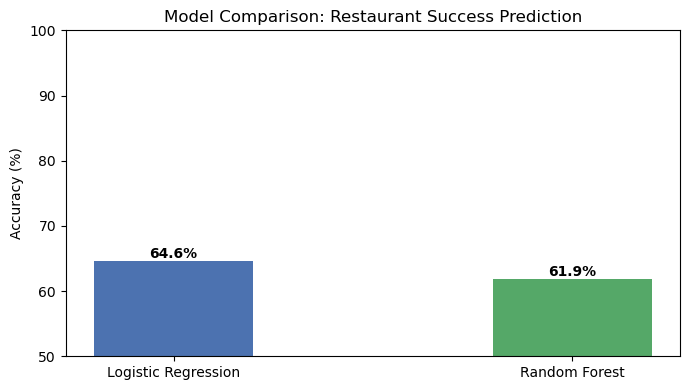

In [11]:
plt.figure(figsize=(7, 4))
models = ["Logistic Regression", "Random Forest"]
accuracies = [lr_acc * 100, rf_acc * 100]
colors = ["#4C72B0", "#55A868"]
bars = plt.bar(models, accuracies, color=colors, width=0.4)
plt.ylim(50, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison: Restaurant Success Prediction")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{acc:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")


In [ ]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 6))
colors_imp = ["#d62728" if imp > 0.1 else "#4C72B0" for imp in importance_df["Importance"]]
plt.barh(importance_df["Feature"], importance_df["Importance"], color=colors_imp)
plt.xlabel("Feature Importance Score")
plt.title("What Drives Restaurant Success? (Random Forest Feature Importance)")
plt.axvline(0.1, color="red", linestyle="--", alpha=0.5, label="High impact threshold")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150)
plt.show()
print("Saved: feature_importance.png")

# Top 5 features
print("\nTop 5 Most Important Features:")
print(importance_df.sort_values("Importance", ascending=False).head(5).to_string(index=False))


In [ ]:
best_preds = rf_preds if rf_acc >= lr_acc else lr_preds
best_name  = "Random Forest" if rf_acc >= lr_acc else "Logistic Regression"

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Rated", "High Rated"],
            yticklabels=["Low Rated", "High Rated"])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

In [ ]:
area_df = df.groupby("area").agg(
    restaurant_count   = ("name", "count"),
    avg_delivery_rating= ("delivery_ratings", "mean"),
    avg_demand_score   = ("demand_score", "mean"),
    avg_opportunity    = ("opportunity_score", "mean"),
    avg_cost           = ("averagecost", "mean")
).reset_index().dropna()

cluster_features = [
    "restaurant_count",
    "avg_delivery_rating",
    "avg_demand_score",
    "avg_opportunity"
]

scaler2 = StandardScaler()
X_cluster = scaler2.fit_transform(area_df[cluster_features])

In [ ]:
inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, "bo-", markersize=8)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Optimal K for Market Segmentation")
plt.tight_layout()
plt.savefig("../outputs/elbow_method.png", dpi=150)
plt.show()
print("Saved: elbow_method.png")

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
area_df["cluster"] = kmeans.fit_predict(X_cluster)

# Label clusters based on characteristics
cluster_summary = area_df.groupby("cluster")[cluster_features].mean()
print("\nCluster Profiles:")
print(cluster_summary.round(2))

In [ ]:
def label_cluster(row):
    density = row["restaurant_count"]
    demand  = row["avg_demand_score"]
    d_med   = area_df["restaurant_count"].median()
    dem_med = area_df["avg_demand_score"].median()
    if density >= d_med and demand >= dem_med:
        return "🔴 Saturated Market"
    elif density < d_med and demand >= dem_med:
        return "🟢 Growth Opportunity"
    elif density < d_med and demand < dem_med:
        return "🟡 Underserved Area"
    else:
        return "🟠 High Competition Low Demand"

area_df["market_zone"] = area_df.apply(label_cluster, axis=1)

In [ ]:
plt.figure(figsize=(10, 6))
colors_map = {
    "🔴 Saturated Market":              "#d62728",
    "🟢 Growth Opportunity":            "#2ca02c",
    "🟡 Underserved Area":              "#f0c417",
    "🟠 High Competition Low Demand":   "#ff7f0e"
}
for zone, grp in area_df.groupby("market_zone"):
    plt.scatter(grp["restaurant_count"], grp["avg_demand_score"],
                label=zone, color=colors_map[zone], alpha=0.7, s=80)

plt.xlabel("Number of Restaurants (Competition)")
plt.ylabel("Average Demand Score")
plt.title("Bangalore Market Segmentation — K-Means Clustering (K=4)")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/market_clustering.png", dpi=150)
plt.show()
print("Saved: market_clustering.png")

# Top Growth Opportunity areas
print("\n🟢 TOP GROWTH OPPORTUNITY AREAS (Best for Expansion):")
growth = area_df[area_df["market_zone"] == "🟢 Growth Opportunity"]
print(growth[["area", "restaurant_count", "avg_delivery_rating",
              "avg_demand_score"]].sort_values(
              "avg_demand_score", ascending=False).head(10).to_string(index=False))

In [ ]:
print("\n" + "="*60)
print("PROJECT ML SUMMARY")
print("="*60)
print(f"  Dataset            : 8,923 restaurants → 3,448 after cleaning")
print(f"  ML Task            : Predict restaurant success (high/low rated)")
print(f"  Logistic Regression: {lr_acc*100:.1f}% accuracy")
print(f"  Random Forest      : {rf_acc*100:.1f}% accuracy  ← Best Model")
print(f"  Clustering         : K-Means (K=4) → 4 market zone types")
print(f"  Areas segmented    : {len(area_df)} unique areas in Bangalore")
print(f"  Growth zones found : {len(growth)} areas ideal for expansion")
print("="*60)
print("\nOutputs saved to ../outputs/")
print("  - model_comparison.png")
print("  - feature_importance.png")
print("  - confusion_matrix.png")
print("  - elbow_method.png")
print("  - market_clustering.png")